In [1]:
import os
import sys

# make lib/ importable from the notebooks/ directory
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from lib import label_images

DATA_DIR = "../data"
LABELS_CSV = DATA_DIR + "/labels.csv"
CACHE_FILE = DATA_DIR + "/split_cache.npz"
IMG_SIZE = (64, 64)
CROP_FRAC = 0.80  # keep central 80% of each axis → drops ~10% border on each side

if not os.path.exists(LABELS_CSV):
    label_images.main()

df = pd.read_csv(LABELS_CSV)

In [2]:

def load_dicom(path, size=IMG_SIZE, crop_frac=CROP_FRAC):
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # center crop — removes border text/watermarks
    h, w = arr.shape
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    arr = arr[y0:y0 + ch, x0:x0 + cw]
    # resize and flatten
    img = Image.fromarray((arr * 255).astype(np.uint8)).resize(size)
    return np.array(img).flatten()


# NOTE: delete data/split_cache.npz whenever CROP_FRAC changes — the cache
# stores flattened pixels and will be stale if the crop parameters differ.
if os.path.exists(CACHE_FILE):
    print(f"Loading split from cache: {CACHE_FILE}")
    print(f"  (cached with CROP_FRAC={CROP_FRAC} — delete cache if this changed)")
    cache = np.load(CACHE_FILE)
    X_train, X_test, y_train, y_test = cache["X_train"], cache["X_test"], cache["y_train"], cache["y_test"]
else:
    df = pd.read_csv(LABELS_CSV)
    print(f"Total images: {len(df)}  |  sick: {(df.label == 1).sum()}  |  not_sick: {(df.label == 0).sum()}")
    print(f"CROP_FRAC={CROP_FRAC}  IMG_SIZE={IMG_SIZE}")

    print("Loading images...")
    X = np.array([load_dicom(p) for p in df["dicom_path"]])
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    np.savez_compressed(CACHE_FILE, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    print(f"Split cached to: {CACHE_FILE}")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Loading split from cache: ../data/split_cache.npz
  (cached with CROP_FRAC=0.8 — delete cache if this changed)
X_train: (23932, 4096)  |  X_test: (5984, 4096)


In [3]:

from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(64, 64, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),  # binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.summary()

I0000 00:00:1774271354.937698   54176 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774271355.003233   54176 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774271356.489179   54176 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1774271356.722909   54176 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,505 (4.35 MB)

 Trainable params: 1,141,505 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Reshape flat vectors → (N, 64, 64, 1) and normalise to [0, 1]
X_tr = X_train.reshape(-1, 64, 64, 1).astype('float32') / 255.0
X_te = X_test.reshape(-1, 64, 64, 1).astype('float32') / 255.0

history = model.fit(
    X_tr, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

# Evaluate on held-out test set
y_prob = model.predict(X_te, batch_size=64).squeeze()
y_pred_cnn = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred_cnn, target_names=['not_sick', 'sick']))

Epoch 1/10


W0000 00:00:1774271357.877969   54176 cpu_allocator_impl.cc:82] Allocation of 352878592 exceeds 10% of free system memory.


337/337 ━━━━━━━━━━━━━━━━━━━━ 71s 207ms/step - accuracy: 0.7368 - loss: 0.5261 - val_accuracy: 0.7565 - val_loss: 0.4970
Epoch 2/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 72s 212ms/step - accuracy: 0.7616 - loss: 0.4985 - val_accuracy: 0.7573 - val_loss: 0.4939
Epoch 3/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 73s 216ms/step - accuracy: 0.7625 - loss: 0.4956 - val_accuracy: 0.7573 - val_loss: 0.4917
Epoch 4/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 74s 219ms/step - accuracy: 0.7692 - loss: 0.4858 - val_accuracy: 0.7652 - val_loss: 0.4870
Epoch 5/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 75s 223ms/step - accuracy: 0.7740 - loss: 0.4791 - val_accuracy: 0.7719 - val_loss: 0.4794
Epoch 6/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 73s 218ms/step - accuracy: 0.7752 - loss: 0.4733 - val_accuracy: 0.7686 - val_loss: 0.4822
Epoch 7/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 90s 267ms/step - accuracy: 0.7822 - loss: 0.4654 - val_accuracy: 0.7732 - val_loss: 0.4762
Epoch 8/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 86s 256ms/step - accuracy: 0.7841 - loss: 0.4601 - val

W0000 00:00:1774272127.523116   54176 cpu_allocator_impl.cc:82] Allocation of 98041856 exceeds 10% of free system memory.


94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step
              precision    recall  f1-score   support

    not_sick       0.81      0.89      0.85      4134
        sick       0.68      0.54      0.60      1850

    accuracy                           0.78      5984
   macro avg       0.75      0.71      0.73      5984
weighted avg       0.77      0.78      0.77      5984



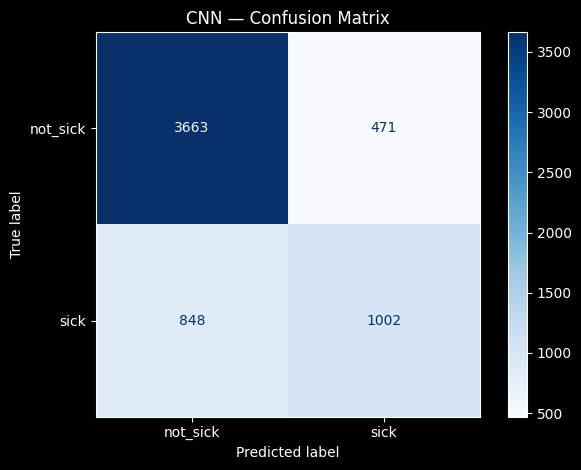

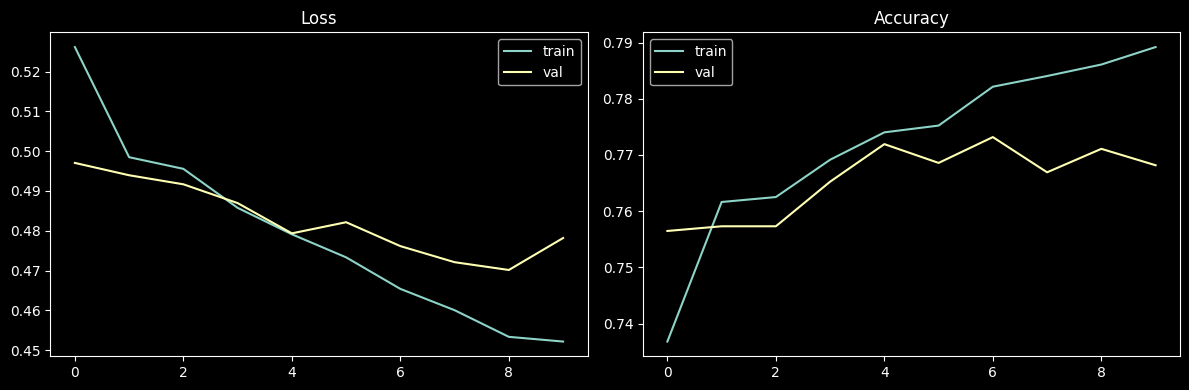

In [5]:
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(cm, display_labels=['not_sick', 'sick'])
disp.plot(cmap='Blues')
plt.title('CNN — Confusion Matrix')
plt.tight_layout()
plt.show()

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss')
ax1.legend()
ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()